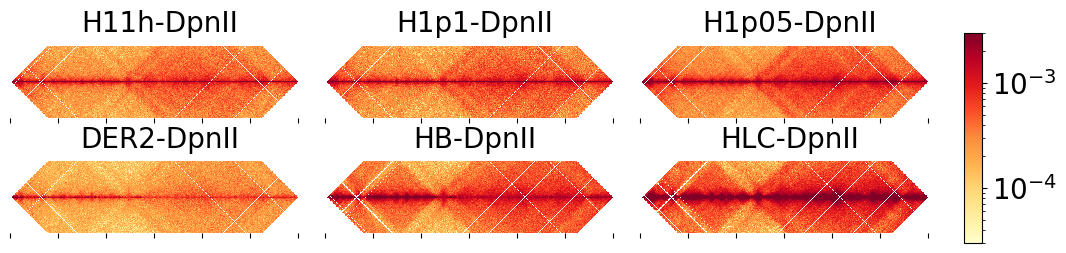

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import cooler
import itertools
from matplotlib.colors import LogNorm
from matplotlib.ticker import EngFormatter
from mpl_toolkits.axes_grid1.inset_locator import inset_axes


def pcolormesh_45deg(ax, matrix_c, start=0, resolution=1, flip_y=False, *args, **kwargs):
    n = matrix_c.shape[0]
    start_pos_vector = [start + resolution * i for i in range(n + 1)]
    t = np.array([[1, 0.5], [-1, 0.5]])
    matrix_a = np.dot(np.array([(i[1], i[0])
                                for i in itertools.product(start_pos_vector[::-1],
                                                           start_pos_vector)]), t)
    x = matrix_a[:, 1].reshape(n + 1, n + 1)
    y = matrix_a[:, 0].reshape(n + 1, n + 1)
    if flip_y:
        y = -y
    im = ax.pcolormesh(x, y, np.flipud(matrix_c), *args, **kwargs)
    im.set_rasterized(True)
    return im


def plot_crane(ax, clr, region, resolution, norm, cmap='YlOrRd', ylim=None):
    data = clr.matrix(balance=True).fetch(region)

    # get genomic start of the region for correct x-axis coordinates
    chrom, start, end = cooler.util.parse_region(region, clr.chromsizes)

    im = pcolormesh_45deg(ax, data, start=start, resolution=resolution, norm=norm, cmap=cmap, flip_y=False)
    pcolormesh_45deg(ax, data, start=start, resolution=resolution, norm=norm, cmap=cmap, flip_y=True)

    # auto-set ylim from region size if not provided
    if ylim is None:
        ylim = (end - start) * 0.5 * 0.6   # ~60% of triangle half-height; tune to taste

    ax.set_ylim(-ylim, ylim)
    ax.set_aspect(0.5)
    ax.xaxis.set_major_formatter(EngFormatter('b'))
    ax.xaxis.tick_bottom()
    ax.set_yticks([])
    ax.set_xticklabels([])
    for s in ('top', 'right', 'bottom', 'left'):
        ax.spines[s].set_visible(False)
    return im


# ---- Configure your samples here ----
resolution = 250_000
region = 'chr1:0-125,000,000'   # <- specific region
norm = LogNorm(vmin=0.00003, vmax=0.003)
ylim = 30_000_000


samples = [
    {'label': 'H11h-DpnII',
     'path': '/MyPath/DL-20250820-LCHCSeq-H1ESC-60mPDp25-DpnII-R3-T1__hg38.hg38.exclude1kb.1000.mcool'},
    {'label': 'H1p1-DpnII',
     'path': '/MyPath/DL-20250820-LCHCSeq-H1ESC-60mPDp10-DpnII-R3-T1__hg38.hg38.exclude1kb.1000.mcool'},
    {'label': 'H1p05-DpnII',
     'path': '/MyPath/DL-20250820-LCHCSeq-H1ESC-60mPDp05-DpnII-R3-T1__hg38.hg38.exclude1kb.1000.mcool'},
    {'label': 'DER2-DpnII',
     'path': '/MyPath/DL-20260616-LCHCSeq-DE-120mPD-DpnII-R2-T1__hg38.hg38.exclude1kb.1000.mcool'},
    {'label': 'HB-DpnII',
     'path': '/MyPath/DL-20250326-LCHCSeq-HB-2hPD-DpnII-R2-T1__hg38.hg38.exclude1kb.1000.mcool'},
    {'label': 'HLC-DpnII',
     'path': '/MyPath/DL-20250326-LCHCSeq-mHep-2hPD-DpnII-R2-T1__hg38.hg38.exclude1kb.1000.mcool'},
    
]

# ---- Grid layout ----
ncols = 3                      # 1 = vertical stack (recommended for wide crane plots)
nrows = int(np.ceil(len(samples) / ncols))

f, axes = plt.subplots(nrows, ncols, figsize=(12, 1.5 * nrows), squeeze=False)
axes = axes.ravel()

im = None
for ax, s in zip(axes, samples):
    clr = cooler.Cooler(f"{s['path']}::/resolutions/{resolution}")
    im = plot_crane(ax, clr, region, resolution, norm, ylim=ylim)
    ax.set_title(s['label'], fontsize=20, pad=10)

# hide any unused axes
for ax in axes[len(samples):]:
    ax.set_visible(False)

# ---- Shared colorbar ----
cax = f.add_axes([0.92, 0.15, 0.015, 0.7])
cbar = f.colorbar(im, cax=cax)
cbar.ax.tick_params(labelsize=20)


plt.subplots_adjust(hspace=0, wspace=0.05, right=0.90)
plt.savefig(f'crane_grid.{region}.{resolution//1000}kb.png',
            bbox_inches='tight', transparent=True)
plt.show()